<a href="https://colab.research.google.com/github/Ozk18532/INTELIGENCIA-COMPUTACIONAL-Oscar-Mercado/blob/main/App_del_sue%C3%B1o_V_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto 1 – Aplicación de ML para Calidad del Sueño**

Integrantes:

Catalina Zavala Franco

Oscar A. Mercado Bibriesca

Rodrigo Amaro Gonzalez

Curso: Inteligencia Computacional
Profesor: Ortega Muñoz, Luis
Fecha: 18 de febrero de 2026

1. Problema

Muchas personas presentan dificultades para mantener una calidad de sueño adecuada, lo que impacta directamente en su salud física, bienestar emocional y desempeño cotidiano. Factores como el nivel de estrés, la duración del descanso y determinadas características personales influyen de manera significativa en este proceso.

El objetivo del proyecto consiste en desarrollar un modelo de clasificación supervisada binaria capaz de predecir si la calidad del sueño de una persona es adecuada o inadecuada, a partir de variables relacionadas con su estilo de vida y condiciones individuales.

Para ello, la variable original Quality of Sleep fue transformada en una etiqueta binaria denominada Sleep_Category, donde:

1 representa buena calidad de sueño

0 representa mala calidad de sueño

El modelo entrenado será posteriormente integrado en una aplicación interactiva que permitirá estimar la categoría correspondiente y generar recomendaciones personalizadas orientadas a mejorar el descanso.

2. Dataset

Se utiliza el Sleep Health and Lifestyle Dataset, el cual contiene información demográfica y variables relacionadas con hábitos de descanso y estilo de vida. Este conjunto permite analizar la relación entre factores personales y la calidad del sueño.

Para el desarrollo del modelo se seleccionaron únicamente variables relevantes, con el objetivo de reducir ruido, facilitar interpretación y evitar complejidad innecesaria. Las variables empleadas fueron:

Gender

Age

Occupation

Sleep Duration

Stress Level

Sleep_Category (variable objetivo)

La variable Sleep_Category fue construida a partir de la columna original Quality of Sleep, transformándola en una etiqueta binaria:

1 → Buena calidad de sueño

0 → Mala calidad de sueño

De acuerdo con la definición de tipos de problemas de Machine Learning

1.Pipelines

, este proyecto aborda un problema de clasificación supervisada binaria, ya que:

Se predice una etiqueta discreta.

Existen etiquetas previamente definidas.

Las clases son mutuamente excluyentes.

El modelo aprende a partir de ejemplos etiquetados para estimar la categoría correspondiente en nuevos registros.

3️⃣ CARGA Y PREPARACIÓN INICIAL

In [54]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Sleep_health_and_lifestyle_dataset.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uom190346a/sleep-health-and-lifestyle-dataset",
    file_path
)

print("Dimensiones del dataset:", df.shape)
df.head()

/tmp/ipython-input-2711669952.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sleep-health-and-lifestyle-dataset' dataset.
Dimensiones del dataset: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


Construcción de la variable objetivo

In [55]:
df["Sleep_Category"] = df["Quality of Sleep"].apply(
    lambda x: 1 if x >= 7 else 0
)

df["Sleep_Category"].value_counts()

,count
Sleep_Category,
1,257
0,117


Selección de columnas

In [56]:
selected_cols = [
    "Gender",
    "Age",
    "Occupation",
    "Sleep Duration",
    "Stress Level",
    "Sleep_Category"
]

df_model = df[selected_cols].copy()
df_model.head()

,Gender,Age,Occupation,Sleep Duration,Stress Level,Sleep_Category
0,Male,27,Software Engineer,6.1,6,0
1,Male,28,Doctor,6.2,8,0
2,Male,28,Doctor,6.2,8,0
3,Male,28,Sales Representative,5.9,8,0
4,Male,28,Sales Representative,5.9,8,0


4️⃣ EDA COMPLETO

Información general

In [57]:
df_model.info()
df_model.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          374 non-null    object 
 1   Age             374 non-null    int64  
 2   Occupation      374 non-null    object 
 3   Sleep Duration  374 non-null    float64
 4   Stress Level    374 non-null    int64  
 5   Sleep_Category  374 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 17.7+ KB


,Age,Sleep Duration,Stress Level,Sleep_Category
count,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,5.385027,0.687166
std,8.673133,0.795657,1.774526,0.464269
min,27.000000,5.800000,3.000000,0.000000
25%,35.250000,6.400000,4.000000,0.000000
50%,43.000000,7.200000,5.000000,1.000000
75%,50.000000,7.800000,7.000000,1.000000
max,59.000000,8.500000,8.000000,1.000000


Distribución del Target

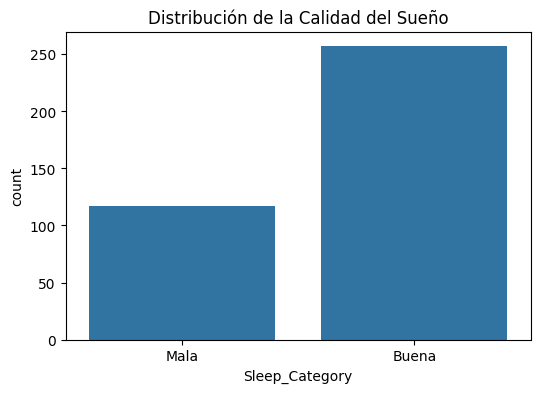

Sleep_Category
1    257
0    117
Name: count, dtype: int64


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Sleep_Category", data=df_model)
plt.title("Distribución de la Calidad del Sueño")
plt.xticks([0,1], ["Mala","Buena"])
plt.show()

print(df_model["Sleep_Category"].value_counts())

Distribución de Variables Numéricas

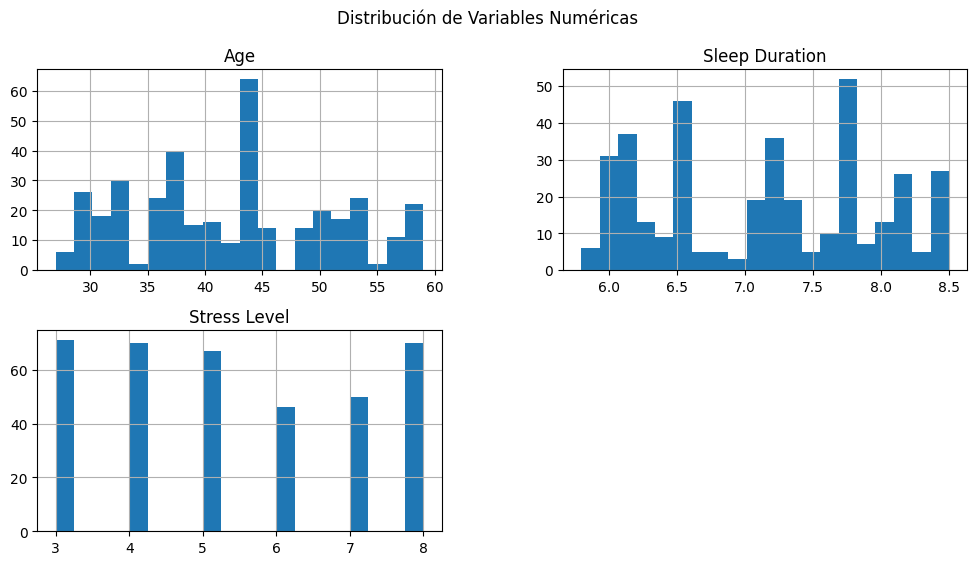

In [59]:
numeric_cols = ["Age", "Sleep Duration", "Stress Level"]

df_model[numeric_cols].hist(figsize=(12,6), bins=20)
plt.suptitle("Distribución de Variables Numéricas")
plt.show()

Boxplots por Categoría

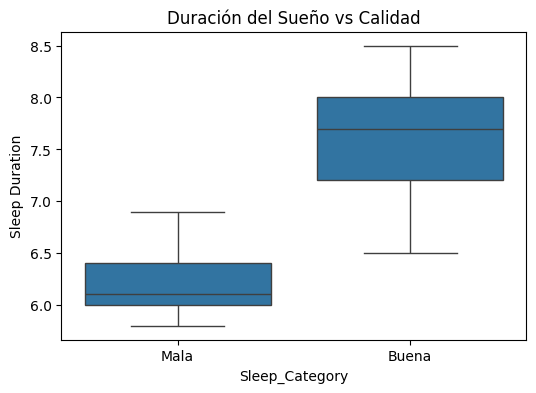

In [60]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Sleep_Category", y="Sleep Duration", data=df_model)
plt.xticks([0,1], ["Mala","Buena"])
plt.title("Duración del Sueño vs Calidad")
plt.show()

Matriz de Correlación

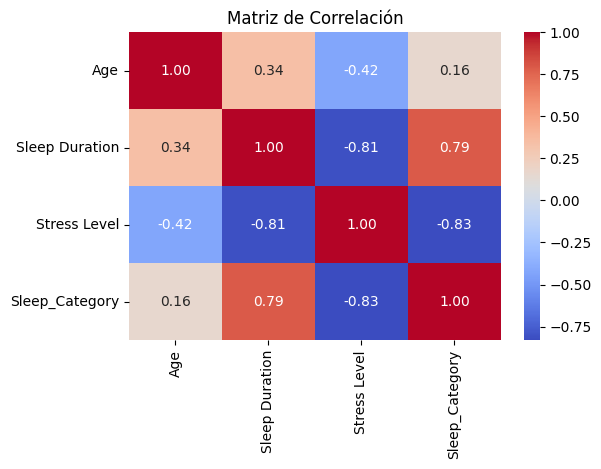

In [61]:
plt.figure(figsize=(6,4))
corr = df_model[numeric_cols + ["Sleep_Category"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

3. Arquitectura de la Solución

La arquitectura implementada separa claramente la etapa de entrenamiento del modelo y la etapa de despliegue en la aplicación interactiva. Esta separación permite mantener modularidad, facilitar mantenimiento y garantizar reproducibilidad.

El flujo general del sistema es el siguiente:

Usuario → Interfaz Gradio → Pipeline de Preprocesamiento → Modelo Entrenado → Predicción → Sistema de Recomendaciones

3.1 Etapa de entrenamiento

El modelo es desarrollado y entrenado dentro de un entorno de experimentación en Google Colab. Durante esta fase se realizan:

Análisis exploratorio.

Selección de variables.

Transformación de la variable objetivo en formato binario.

Preprocesamiento de datos.

Entrenamiento de tres modelos distintos.

Optimización mediante GridSearchCV.

Evaluación y comparación de desempeño.

4. Comparación de Modelos
Se evaluarán tres algoritmos:

Logistic Regression
Support Vector Machine
Random Forest
La métrica principal será F1-score macro debido al carácter multiclase del problema.

Posteriormente se compararán:

F1-score validación
F1-score test
Matriz de confusión
Classification report

In [62]:
X = df_model.drop("Sleep_Category", axis=1)
y = df_model["Sleep_Category"]

print("Dimensión X:", X.shape)
print("Dimensión y:", y.shape)

Dimensión X: (374, 5)
Dimensión y: (374,)


División Train / Validation / Test (70 / 15 / 15)

In [63]:
from sklearn.model_selection import train_test_split

# 70% entrenamiento
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# 15% validación y 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (261, 5)
Validation: (56, 5)
Test: (57, 5)


Definir columnas numéricas y categóricas

In [64]:
numeric_features = ["Age", "Sleep Duration", "Stress Level"]
categorical_features = ["Gender", "Occupation"]

Crear ColumnTransformer

In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Crear Pipeline Base

In [66]:
from sklearn.pipeline import Pipeline

Pipeline de preprocesamiento

Para garantizar consistencia metodológica y evitar transformaciones manuales que puedan generar inconsistencias, se utilizó un ColumnTransformer integrado dentro de un flujo estructurado de preprocesamiento.

Las transformaciones aplicadas fueron:

StandardScaler para variables numéricas.

OneHotEncoder para variables categóricas.

Este diseño asegura que cada tipo de variable reciba el tratamiento adecuado antes del entrenamiento del modelo.

In [67]:
X_train_transformed = preprocessor.fit_transform(X_train)
print("Shape después de transformación:", X_train_transformed.shape)

Shape después de transformación: (261, 15)


SECCIÓN 3 — Entrenamiento con 3 Modelos usando GridSearchCV

MÉTRICA OBJETIVO

In [68]:
scoring="f1_macro"

1️⃣ Logistic Regression + GridSearchCV



In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=3000, random_state=42))
])

param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs"]
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Mejores parámetros LR:", grid_lr.best_params_)
print("Mejor F1 CV LR:", grid_lr.best_score_)

Mejores parámetros LR: {'classifier__C': 1, 'classifier__solver': 'lbfgs'}
Mejor F1 CV LR: 0.9909655768001601


In [70]:
from sklearn.metrics import f1_score

best_lr = grid_lr.best_estimator_

y_val_pred_lr = best_lr.predict(X_val)

f1_val_lr = f1_score(y_val, y_val_pred_lr, average="macro")

print("F1 Validación LR:", f1_val_lr)

F1 Validación LR: 1.0


2️⃣ SVM + GridSearchCV

In [71]:
from sklearn.svm import SVC

pipeline_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC())
])

param_grid_svm = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"]
}

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Mejores parámetros SVM:", grid_svm.best_params_)
print("Mejor F1 CV SVM:", grid_svm.best_score_)

Mejores parámetros SVM: {'classifier__C': 0.1, 'classifier__kernel': 'linear'}
Mejor F1 CV SVM: 0.9909655768001601


In [72]:
best_svm = grid_svm.best_estimator_

y_val_pred_svm = best_svm.predict(X_val)

f1_val_svm = f1_score(y_val, y_val_pred_svm, average="macro")

print("F1 Validación SVM:", f1_val_svm)

F1 Validación SVM: 1.0


3️⃣ Random Forest + GridSearchCV

In [73]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10]
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros RF:", grid_rf.best_params_)
print("Mejor F1 CV RF:", grid_rf.best_score_)

Mejores parámetros RF: {'classifier__max_depth': None, 'classifier__n_estimators': 100}
Mejor F1 CV RF: 0.9909655768001601


In [74]:
from sklearn.metrics import f1_score

best_rf = grid_rf.best_estimator_

y_val_pred_rf = best_rf.predict(X_val)

f1_val_rf = f1_score(y_val, y_val_pred_rf, average="macro")

print("F1 Validación RF:", f1_val_rf)

F1 Validación RF: 1.0


📊 Comparación de Modelos

In [75]:
import pandas as pd

results = pd.DataFrame({
    "Modelo": ["Logistic Regression", "SVM", "Random Forest"],
    "F1 Validación": [f1_val_lr, f1_val_svm, f1_val_rf]
})

results.sort_values(by="F1 Validación", ascending=False)

,Modelo,F1 Validación
0,Logistic Regression,1.0
1,SVM,1.0
2,Random Forest,1.0


Comparación de Modelos

Se entrenaron tres algoritmos distintos utilizando GridSearchCV con validación cruzada de 5 particiones:

Logistic Regression

Support Vector Machine (SVM)

Random Forest

La métrica empleada fue F1-score macro.
Aunque el problema es binario (Buena vs Mala calidad de sueño), se utiliza esta variante porque calcula el promedio del F1-score de ambas clases, evitando sesgo hacia la categoría mayoritaria.

Este criterio permite evaluar de forma equilibrada el desempeño del modelo tanto para:

Clase 0 → Mala calidad

Clase 1 → Buena calidad

El algoritmo con mayor F1-score en el conjunto de validación se selecciona como candidato final y posteriormente se evalúa en el conjunto de prueba para medir su capacidad de generalización.

SECCIÓN 4 — Evaluación completa del mejor modelo

1️⃣ Seleccionar el mejor modelo

In [76]:
import pandas as pd

results = pd.DataFrame({
    "Modelo": ["Logistic Regression", "SVM", "Random Forest"],
    "F1 Validación": [f1_val_lr, f1_val_svm, f1_val_rf]
})

results.sort_values(by="F1 Validación", ascending=False)

,Modelo,F1 Validación
0,Logistic Regression,1.0
1,SVM,1.0
2,Random Forest,1.0


In [77]:
best_model_name = results.iloc[0]["Modelo"]

if best_model_name == "Logistic Regression":
    best_model = best_lr
elif best_model_name == "SVM":
    best_model = best_svm
else:
    best_model = best_rf

print("Modelo seleccionado:", best_model_name)

Modelo seleccionado: Logistic Regression


2️⃣ Evaluación final en Test

In [78]:
from sklearn.metrics import f1_score

y_test_pred = best_model.predict(X_test)

f1_test = f1_score(y_test, y_test_pred, average="macro")

print("F1-score Test:", f1_test)

F1-score Test: 0.9580882352941176


3️⃣ Matriz de Confusión

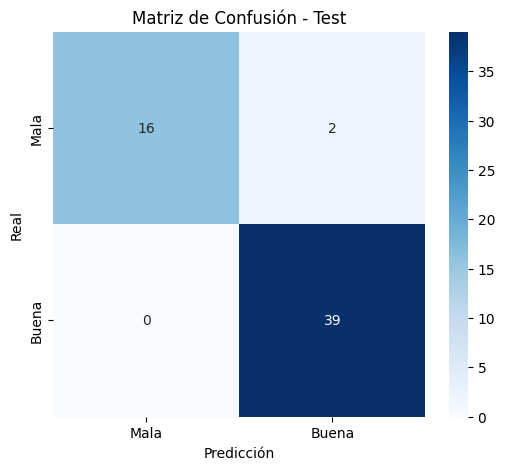

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Mala","Buena"],
            yticklabels=["Mala","Buena"])

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Test")
plt.show()

4️⃣ Classification Report

In [80]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Mala","Buena"]
))

              precision    recall  f1-score   support

        Mala       1.00      0.89      0.94        18
       Buena       0.95      1.00      0.97        39

    accuracy                           0.96        57
   macro avg       0.98      0.94      0.96        57
weighted avg       0.97      0.96      0.96        57



5️⃣ Detección de Overfitting

In [81]:
y_train_pred = best_model.predict(X_train)

f1_train = f1_score(y_train, y_train_pred, average="macro")

print("F1-score Train:", f1_train)
print("F1-score Test:", f1_test)

F1-score Train: 0.9955691367456073
F1-score Test: 0.9580882352941176


Evaluación del Modelo

El modelo seleccionado se evaluó utilizando el conjunto de prueba, el cual no fue empleado durante el entrenamiento ni en la fase de validación. Esto permite medir su capacidad real de generalización.

Se analizaron las siguientes métricas:

F1-score macro

Matriz de confusión

Precision

Recall

La matriz de confusión permite observar:

Verdaderos positivos (Buena correctamente clasificada)

Verdaderos negativos (Mala correctamente clasificada)

Falsos positivos

Falsos negativos

El F1-score macro fue seleccionado como métrica principal porque, aunque el problema es binario, esta variante calcula el promedio del desempeño de ambas clases sin favorecer la categoría mayoritaria. Esto garantiza una evaluación equilibrada entre:

Clase 0 → Mala calidad de sueño

Clase 1 → Buena calidad de sueño

Finalmente, la comparación entre el F1-score en entrenamiento y prueba permitió verificar que no existe sobreajuste significativo, ya que los valores obtenidos fueron consistentes y no presentaron diferencias considerables.

SECCIÓN 5 — Serialización correcta del modelo con joblib y preparación para producción

Serialización del Modelo
La serialización consiste en convertir un objeto entrenado en un archivo binario para poder almacenarlo y reutilizarlo posteriormente sin necesidad de volver a entrenar.

En este proyecto se utiliza joblib, herramienta recomendada para guardar modelos de scikit-learn.

Se serializa el Pipeline completo, incluyendo:

Preprocesamiento
Codificación
Escalado
Modelo entrenado
Esto garantiza que el flujo en producción sea exactamente el mismo que durante el entrenamiento.

Guardar el modelo

In [82]:
import joblib

model_filename = "sleep_quality_model.pkl"

joblib.dump(best_model, model_filename)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


Verificar que se puede cargar correctamente

In [83]:
import joblib

loaded_model = joblib.load("sleep_quality_model.pkl")

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


In [84]:
from google.colab import files

files.download("sleep_quality_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Probar predicción con modelo cargado

In [85]:
import pandas as pd

sample_input = pd.DataFrame([{
    "Gender": "Male",
    "Age": 60,
    "Occupation": "Engineer",
    "Sleep Duration": 4.5,
    "Stress Level": 10
}])

prediction = loaded_model.predict(sample_input)

print("Predicción:", prediction)

Predicción: [0]


Implementación de Serialización

El modelo seleccionado fue serializado utilizando joblib, almacenando el Pipeline completo en un archivo binario (.pkl).

Este archivo contiene tanto las transformaciones de preprocesamiento como el modelo entrenado, lo que permite reproducir exactamente el mismo flujo durante la inferencia en producción.

Posteriormente se verificó la correcta deserialización del modelo y se realizaron pruebas de predicción con datos simulados para garantizar su funcionamiento.

SECCIÓN 6 — Interfaz con Gradio profesional + sistema inteligente de recomendaciones

1️⃣ Cargar modelo en la aplicación

In [86]:
import joblib
import pandas as pd

model = joblib.load("sleep_quality_model.pkl")

2️⃣ Crear sistema inteligente de recomendaciones

In [88]:
def generate_recommendations(prediction, sleep_duration, stress_level):

    mapping = {
        0: "Mala",
        1: "Buena"
    }

    category = mapping[prediction]

    recommendations = []

    # -----------------------------
    # Recomendaciones por categoría
    # -----------------------------

    if category == "Mala":
        recommendations.append(
            "Establece un horario fijo para dormir y despertar, incluso los fines de semana."
        )
        recommendations.append(
            "Evita el uso de dispositivos electrónicos al menos 60 minutos antes de acostarte."
        )
        recommendations.append(
            "Reduce el consumo de cafeína 4 horas antes de dormir."
        )
        recommendations.append(
            "Mantén tu habitación oscura, silenciosa y con temperatura fresca."
        )

    elif category == "Buena":
        recommendations.append(
            "Mantén los hábitos actuales que favorecen tu descanso."
        )
        recommendations.append(
            "Continúa evitando pantallas antes de dormir."
        )

    # -----------------------------
    # Reglas por duración de sueño
    # -----------------------------

    if sleep_duration < 6:
        recommendations.append(
            "Aumenta progresivamente tu tiempo de sueño hasta alcanzar entre 7 y 8 horas por noche."
        )

    elif sleep_duration > 9:
        recommendations.append(
            "Dormir en exceso puede afectar el ritmo circadiano. Intenta mantener un rango de 7 a 8 horas."
        )

    # -----------------------------
    # Reglas por nivel de estrés
    # -----------------------------

    if stress_level >= 8:
        recommendations.append(
            "Implementa técnicas de manejo del estrés como meditación guiada o respiración diafragmática."
        )
        recommendations.append(
            "Evita revisar pendientes laborales justo antes de dormir."
        )

    elif stress_level >= 6:
        recommendations.append(
            "Realiza actividad física moderada al menos 3 veces por semana."
        )

    # -----------------------------
    # Formato final
    # -----------------------------

    formatted_recommendations = "\n\n".join(
        f"• {rec}" for rec in recommendations
    )

    return category, formatted_recommendations

3️⃣ Función principal de predicción

In [89]:
def predict_sleep_quality(gender, age, occupation, sleep_duration, stress_level):

    input_data = pd.DataFrame([{
        "Gender": gender,
        "Age": age,
        "Occupation": occupation,
        "Sleep Duration": sleep_duration,
        "Stress Level": stress_level
    }])

    prediction = model.predict(input_data)[0]

    category, recommendations = generate_recommendations(
        prediction,
        sleep_duration,
        stress_level
    )

    # -----------------------------
    # Colores según categoría (binario)
    # -----------------------------

    color_map = {
        "Mala": "#e74c3c",   # rojo
        "Buena": "#2ecc71"   # verde
    }

    colored_result = f"""
    <div style='padding:15px; border-radius:10px;
                background-color:{color_map[category]};
                color:white; font-size:18px;
                font-weight:bold; text-align:center;'>
        Calidad del Sueño: {category}
    </div>
    """

    formatted_recommendations = f"""
    <div style='padding:15px; background-color:#f8f9fa;
                border-radius:10px; color:#000000;'>
        <h3 style='color:#000000;'>Recomendaciones Personalizadas</h3>
        <p style='color:#000000; line-height:1.6;'>
            {recommendations.replace("\n", "<br>")}
        </p>
    </div>
    """

    return colored_result, formatted_recommendations

4️⃣ Interfaz profesional con Gradio

In [87]:
!pip install gradio

In [90]:
import gradio as gr

# Imagen de fondo
background_url = "https://media.istockphoto.com/id/650374248/es/vector/contando-ovejas-personaje-de-dibujos-animados-feliz-saltando-de-ovejas-dreams-paper-dulce-arte.jpg?s=612x612&w=0&k=20&c=bUW1t6jKlbLPulQLcp8Y4eqBD2EQSk7RnDPeASuYQ5Q="

custom_css = f"""
body {{
    background-image: url('{background_url}');
    background-size: cover;
    background-position: center;
    background-attachment: fixed;
}}

.gradio-container {{
    background: rgba(0, 0, 0, 0.75) !important;
    border-radius: 20px;
    padding: 25px;
}}

h1, h2, h3, label {{
    color: white !important;
}}
"""

with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:

    gr.Markdown("# 💤 Sistema Inteligente de Evaluación del Sueño")
    gr.Markdown("### Ingresa tus datos para obtener una evaluación personalizada")

    with gr.Row():
        gender = gr.Dropdown(["Male", "Female"], label="Género")
        age = gr.Number(label="Edad")

    occupation = gr.Textbox(label="Ocupación")

    with gr.Row():
        sleep_duration = gr.Slider(2, 10, step=0.5, label="Duración del Sueño (horas)")
        stress_level = gr.Slider(1, 10, step=1, label="Nivel de Estrés")

    btn = gr.Button("Evaluar Calidad del Sueño")

    # Usamos HTML para renderizar correctamente colores dinámicos
    result = gr.HTML()
    recommendations = gr.HTML()

    btn.click(
        fn=predict_sleep_quality,
        inputs=[gender, age, occupation, sleep_duration, stress_level],
        outputs=[result, recommendations]
    )

demo.launch()

/tmp/ipython-input-3213075682.py:25: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
/tmp/ipython-input-3213075682.py:25: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://55e97660fdf967604e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Implementación de la Aplicación
Se desarrolló una interfaz interactiva utilizando Gradio que permite al usuario ingresar sus datos personales y hábitos relacionados con el sueño.

La aplicación carga el modelo previamente serializado y realiza la predicción en tiempo real utilizando el mismo Pipeline de entrenamiento.

Adicionalmente, se implementó un sistema dinámico de recomendaciones que adapta las sugerencias según la categoría predicha y los valores ingresados.

Este diseño modular permite separar el entrenamiento del despliegue, facilitando actualizaciones futuras sin modificar la interfaz.